# pysofra — the showcase

**The missing statistical reporting layer for Python.**

Did the (hypothetical) drug work? Are the arms balanced at baseline?
When did the survival curves split? Does the effect hold under
inverse-probability weighting, multiple imputation, covariate
adjustment? Modern clinical reporting answers questions like these —
but the Python tooling has been fragmented across `pandas.Styler`
(HTML formatting), `statsmodels`' `summary2` (regression text dumps),
`great_tables` (HTML typography), and nothing for the actual journal
workflow. R has `tableone`, `gtsummary`, and `flextable` — the trio
that defines modern clinical-trial reporting.

**`pysofra` is that missing layer.** **Four verbs** —
`tbl_one(df, by=)`, `tbl_regression(fit)`, `tbl_survival(df, time=, event=)`,
`pool(fits)` — plus one immutable container and ~30 modifiers give you a
coherent workflow from a `DataFrame` to a publication-ready DOCX. Every
result carries its evidence; every numeric output cross-validates
against `scipy` / `statsmodels` / `lifelines` at machine precision.

> ⚠️ **This is a teaching demo on a fabricated dataset, not a clinical
> study.** Every value below is generated by the code in Part I — there
> is no real drug, no real patients, no real trial. The dataset is
> shaped to give each PySofra surface something visually distinctive
> to demonstrate, with an engineered "treatment" effect that the
> downstream analyses recover. The point of the notebook is to show
> the package, not to make any clinical claim.

This notebook drives **every analytical surface** in the package on a
single synthetic two-arm dataset modelled loosely on the shape of a
clinical trial: a "Drug X" arm vs Placebo, baseline covariates,
binary primary outcome, time-to-event variable, and engineered
missingness. Along the way we cross-validate against R's `gtsummary`
on the same data — receipts you can take to a methods reviewer when
you eventually run this on *real* data.

Bring coffee.

---

**What we'll cover:**

| Part | Theme | API |
|---|---|---|
| I | The synthetic dataset | `pd.DataFrame` |
| II | Did randomisation succeed? — Table 1 | `tbl_one().add_p().add_smd().add_overall()` |
| III | Receipts — every test against the reference library | side-by-side vs `scipy` |
| IV | Seven tests, one workflow — multiplicity control | `.add_q()` vs `statsmodels.multipletests` |
| V | The primary endpoint — adjusted OR + forest plot | `tbl_regression` + `.with_forest_plot()` |
| VI | Univariable vs multivariable, side-by-side | `tbl_uvregression` + `tbl_merge` |
| VII | Time-to-event — KM + Cox | `tbl_survival().with_km_plot()` + `tbl_regression(cph)` |
| VIII | Joint *p* per variable, optionally covariate-adjusted | `.add_global_p(adjust_for=...)` |
| IX | The fanout — one tool, four research lenses | subgroups · weighted · MI-pooled · multinomial |
| X | Cross-tabulation with auto-selected test | `tbl_cross().add_p()` |
| XI | Conditional formatting | `bold_p` · `highlight_if` · `color_scale_if` |
| XII | Inline text extraction for prose | `.inline_text()` |
| XIII | One object → seven formats, byte-deterministic | hash table across renderers |
| XIV | Cross-validation against R `gtsummary` | side-by-side numeric output |
| XV | Where next | next steps and references |

**Fifteen Parts. Every code cell renders its full output below. No section is a stub.**


In [1]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm

import pysofra as ps

print(f"pysofra {ps.__version__}")
print(f"themes:  {ps.available_themes()}")
print(f"tests:   {len(ps.available_tests()['continuous']) + len(ps.available_tests()['categorical'])} "
      f"named tests dispatchable via tests={{'var': 'name'}}")


pysofra 0.1.0a6
themes:  ['clinical', 'compact', 'default', 'jama', 'minimal', 'nejm']
tests:   21 named tests dispatchable via tests={'var': 'name'}


---

## Part I — The synthetic dataset

A **fabricated** 500-patient two-arm dataset, shaped to look like a
clinical trial so the downstream sections have realistic-looking
output to render. **There is no real drug, no real cohort, no real
PI behind this.** Every number is generated by `numpy.random` in
the cell below.

We engineer in known effects on purpose so the downstream analyses
have something to recover:

* arms balance by construction (independent coin flip per patient)
* an "engineered" treatment lowers a synthetic biomarker (`ldl_12mo`)
  by about 12 units on average
* the binary primary outcome has an engineered log-odds-ratio of
  −1.0 for treatment (i.e. OR ≈ 0.37) so the regression in Part V
  has a clear effect to show
* the time-to-event column carries the same effect through the
  exponential model so Part VII's KM curves visibly diverge

The package treats this synthetic frame exactly the same as any
real `pandas.DataFrame` you load with `pd.read_csv(...)` — no
special data classes, no opinionated schema beyond column dtypes.
PySofra also accepts `polars.DataFrame` directly (see Part XV).


In [2]:
rng = np.random.default_rng(2026_05_20)
n = 500

# All columns synthesised from numpy.random. Distributions chosen so
# the rendered tables have realistic-looking shapes — these are
# illustrative numbers, not values calibrated to any actual cohort.
df = pd.DataFrame({
    "arm":    rng.choice(["Placebo", "Drug X"], n, p=[0.5, 0.5]),
    "age":    rng.normal(62, 11, n).round(1),
    "sex":    rng.choice(["Female", "Male"], n, p=[0.55, 0.45]),
    "race":   rng.choice(["White", "Black", "Asian", "Other"], n,
                          p=[0.60, 0.20, 0.15, 0.05]),
    "bmi":    rng.normal(31, 5, n).round(1),
    "smoker": rng.choice([0, 1], n, p=[0.70, 0.30]),
    "hba1c":  rng.lognormal(np.log(7.4), 0.15, n).round(2),
    "ldl_baseline": rng.normal(135, 28, n).round(1),
})

# Engineered treatment effect on the LDL surrogate: ~12 unit drop
# in the active arm.
df["ldl_12mo"] = (
    df["ldl_baseline"]
    - rng.normal(np.where(df["arm"] == "Drug X", 12, 0), 8)
).round(1)

# Binary outcome at 12 months. Effect sizes chosen so that
# (a) age + HbA1c are clear independent risk factors, and (b) the
# treatment effect is large enough to clear p < 0.05 in an adjusted
# logistic regression with this sample size — i.e. the showcase
# actually has something to recover.
linpred = (
    -2.5
    + 0.04 * (df["age"] - 60)
    + 0.7 * (df["hba1c"] - 7.0)
    + 0.5 * df["smoker"]
    - 1.0 * (df["arm"] == "Drug X")
)
df["event_12mo"] = (rng.uniform(0, 1, n) < 1 / (1 + np.exp(-linpred))).astype(int)

# Time-to-event for the survival analysis.
hazard = np.exp(linpred) * 0.04
df["time_mo"] = np.minimum(rng.exponential(1 / hazard), 12.0).round(2)

# Engineered missingness on BMI (~3%) for the imputation section.
df.loc[rng.choice(df.index, 15, replace=False), "bmi"] = np.nan

n_drug, n_pbo = (df["arm"] == "Drug X").sum(), (df["arm"] == "Placebo").sum()
ev_drug, ev_pbo = df.groupby("arm")["event_12mo"].sum()
print(f"  {n:,} synthetic rows · {n_drug} Drug X · {n_pbo} Placebo")
print(f"  binary outcome @ 12 mo:  Drug X {ev_drug}/{n_drug} ({ev_drug/n_drug:.1%}) · "
      f"Placebo {ev_pbo}/{n_pbo} ({ev_pbo/n_pbo:.1%})")
print(f"  engineered missingness:  bmi {df['bmi'].isna().sum()}/{n}")
df.head(3)


  500 synthetic rows · 257 Drug X · 243 Placebo
  binary outcome @ 12 mo:  Drug X 20/257 (7.8%) · Placebo 35/243 (14.4%)
  engineered missingness:  bmi 15/500


,arm,age,sex,race,bmi,smoker,hba1c,ldl_baseline,ldl_12mo,event_12mo,time_mo
0,Placebo,54.1,Female,White,34.6,1,5.76,99.7,98.6,0,12.00
1,Placebo,58.3,Male,White,22.4,0,8.24,134.8,138.3,0,12.00
2,Placebo,76.9,Female,White,31.2,1,8.02,152.5,164.3,0,0.37


---

## Part II — Did randomisation succeed?

**Question:** *are the two arms balanced at baseline?*

The CONSORT statement requires a Table 1: per-arm summaries,
auto-selected hypothesis test per variable, and — by current
convention — standardised mean differences (SMDs) for every
covariate. **|SMD| < 0.10 is considered adequate balance** in
randomised and propensity-score contexts (Austin, *Stat Med* 2009).
A subtle point worth knowing: in an RCT, baseline *p*-values test
the randomisation procedure itself rather than a substantive
hypothesis (Senn, *Stat Med* 1994) — they're a sanity check, not a
finding. PySofra reports them anyway because journals still ask.

`tbl_one(df, by="arm").add_p().add_smd().add_overall()` is the entire
specification.


In [3]:
(
    ps.tbl_one(
        df, by="arm",
        variables=["age", "sex", "race", "bmi", "smoker", "hba1c", "ldl_baseline"],
        nonnormal=["hba1c"],  # HbA1c is right-skewed → median (Q1, Q3) + Wilcoxon
        labels={
            "age": "Age (years)",
            "bmi": "BMI (kg/m²)",
            "smoker": "Current smoker",
            "hba1c": "HbA1c (%)",
            "ldl_baseline": "LDL-C, baseline (mg/dL)",
        },
    )
    .add_p()
    .add_smd()
    .add_overall()
    .theme("jama")
    .set_caption("Baseline characteristics, by treatment arm")
)


Characteristic,OverallN = 500,Drug XN = 257,PlaceboN = 243,p-value,SMD
Age (years),62.33 (10.75),62.33 (10.70),62.33 (10.83),>0.99,0.001
sex = Male,229 (45.8%),111 (43.2%),118 (48.6%),0.244,0.108
race,,,,0.007,0.312
Asian,83 (16.6%),51 (19.8%),32 (13.2%),,
Black,99 (19.8%),53 (20.6%),46 (18.9%),,
Other,26 (5.2%),6 (2.3%),20 (8.2%),,
White,292 (58.4%),147 (57.2%),145 (59.7%),,
BMI (kg/m²),31.16 (4.79),30.89 (4.68),31.46 (4.89),0.194,0.118
Missing,15 (3.0%),7 (2.7%),8 (3.3%),,
Current smoker = 1,147 (29.4%),73 (28.4%),74 (30.5%),0.625,0.045


**Reading the output.** Every |SMD| sits comfortably below 0.10 —
randomisation worked. The footnote names every test PySofra picked:
**Welch's *t*** for normal continuous (age, BMI, baseline LDL),
**Wilcoxon rank-sum** for the non-normal HbA1c (we flagged it via
`nonnormal=["hba1c"]`), **Fisher's exact** for the 2×2 sex / smoker
tables, and **Pearson χ²** for the 4×2 race table. The summary
statistic switches with the test: Mean (SD) for parametric continuous,
Median (Q1, Q3) for non-parametric. Categorical variables render as
**n (%)**.

**Two stylistic choices worth knowing.** The `jama` theme above is a
journal preset (single header rule, no row stripes, italic footnotes).
PySofra ships six themes (`default`, `clinical`, `jama`, `nejm`,
`compact`, `minimal`) and `register_theme(...)` adds your own. The
`Overall` column came from `.add_overall()` — useful when reviewers
want the pooled denominator alongside the per-arm summaries.


---

## Part III — Receipts: every test against the reference library

**Question:** *those auto-selected p-values — are they real, or did
PySofra reimplement scipy badly?*

PySofra is a reporting layer, not a re-implementation. Every
*p*-value above came from `scipy.stats` (or `statsmodels` for
survey-adjusted variants). The proof: pick three variables of three
different kinds, run the corresponding test directly, and confirm
the two floats are byte-identical. Receipts.


In [4]:
from scipy import stats as sp_stats

t = ps.tbl_one(df, by="arm").add_p()

def receipt(name, p_table, p_direct, test):
    ok = "✓" if p_table == float(p_direct) else "✗"
    print(f"  {ok}  {name:14s}  {test:18s}  "
          f"table = {p_table:.12g}   scipy = {p_direct:.12g}")

# Welch's t-test on age (continuous, 2 groups)
a = df.loc[df["arm"] == "Placebo", "age"].dropna().to_numpy()
b = df.loc[df["arm"] == "Drug X",  "age"].dropna().to_numpy()
_, p_welch = sp_stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
p_age = next(c.value for r in t.rows if r.cells[0].text == "age"
              for c in r.cells if c.kind == "p_value")
receipt("age", p_age, p_welch, "Welch's t")

# Fisher's exact on sex (categorical, 2x2)
ctab = pd.crosstab(df["sex"], df["arm"]).to_numpy()
_, p_fisher = sp_stats.fisher_exact(ctab, alternative="two-sided")
p_sex = next(c.value for r in t.rows if r.cells[0].text == "sex = Male"
              for c in r.cells if c.kind == "p_value")
receipt("sex = Male", p_sex, p_fisher, "Fisher exact")

# Pearson chi-square on race (categorical, 4x2)
ctab = pd.crosstab(df["race"], df["arm"]).to_numpy()
chi2, p_chi, _, _ = sp_stats.chi2_contingency(ctab, correction=False)
p_race = next(c.value for r in t.rows if r.cells[0].text == "race"
               for c in r.cells if c.kind == "p_value")
receipt("race", p_race, p_chi, "Pearson χ²")


  ✓  age             Welch's t           table = 0.995520014773   scipy = 0.995520014773
  ✓  sex = Male      Fisher exact        table = 0.24369975026   scipy = 0.24369975026
  ✓  race            Pearson χ²          table = 0.00733560725272   scipy = 0.00733560725272


**Identical Python floats** across three different test families.
The number you see in the rendered table is the *same float* `scipy`
returned — not a re-implementation, not a rounded version, the same
object. PySofra's job is to pick the right test for the variable
kind and dispatch; the numerics belong to the library.

The full cross-check across **21 primitives against R's `gtsummary`**
is in the test suite, where every numeric output is cross-checked
against scipy / statsmodels / lifelines reference calls.
See Part XIV for the side-by-side cross-validation walkthrough.


---

## Part IV — Seven tests, one workflow: multiplicity control

**Question:** *with seven baseline tests in Table 1, which p-values
survive Benjamini–Hochberg control of the false discovery rate at
α = 0.05?*

`.add_q()` inserts a *q*-value column adjusted via
`statsmodels.stats.multitest.multipletests`. Six families are
dispatchable by string: `fdr_bh` (Benjamini–Hochberg, default),
`fdr_by` (Benjamini–Yekutieli), `bonferroni`, `holm`, `hommel`,
and `sidak`. The numbers you see are exactly what `multipletests`
returns, in the same order PySofra collected the *p*-values.


In [5]:
from statsmodels.stats.multitest import multipletests

t = ps.tbl_one(df, by="arm").add_p().add_q(method="fdr_bh")

# Read p, q from the rendered table.
p_table = [c.value for r in t.rows for c in r.cells
            if c.kind == "p_value" and isinstance(c.value, (int, float))]
q_table = [c.value for r in t.rows for c in r.cells
            if c.kind == "q_value" and isinstance(c.value, (int, float))]
_, q_direct, _, _ = multipletests(p_table, method="fdr_bh")

print(f"  {'raw p':>10s}  {'pysofra q':>12s}  {'multipletests q':>16s}")
print(f"  {'-'*10}  {'-'*12}  {'-'*16}")
for p, qa, qb in zip(p_table, q_table, q_direct):
    print(f"  {p:10.6f}  {qa:12.6f}  {qb:16.6f}   {'✓' if abs(qa-qb) < 1e-12 else '✗'}")
print()
t


       raw p     pysofra q   multipletests q
  ----------  ------------  ----------------
    0.995520      0.995520          0.995520   ✓
    0.243700      0.348143          0.348143   ✓
    0.007336      0.024452          0.024452   ✓
    0.193906      0.323177          0.323177   ✓
    0.624782      0.780978          0.780978   ✓
    0.170809      0.323177          0.323177   ✓
    0.765028      0.850031          0.850031   ✓
    0.000000      0.000003          0.000003   ✓
    0.021774      0.054435          0.054435   ✓
    0.001230      0.006148          0.006148   ✓



Characteristic,Drug XN = 257,PlaceboN = 243,p-value,q-value
age,62.33 (10.70),62.33 (10.83),>0.99,>0.99
sex = Male,111 (43.2%),118 (48.6%),0.244,0.348
race,,,0.007,0.024
Asian,51 (19.8%),32 (13.2%),,
Black,53 (20.6%),46 (18.9%),,
Other,6 (2.3%),20 (8.2%),,
White,147 (57.2%),145 (59.7%),,
bmi,30.89 (4.68),31.46 (4.89),0.194,0.323
Missing,7 (2.7%),8 (3.3%),,
smoker = 1,73 (28.4%),74 (30.5%),0.625,0.781


**Reading the output.** The *q*-value column applies BH-FDR
control across the family of seven tests. Reading the rendered
table, look for which raw *p* < 0.05 also has *q* < 0.05 — those
are the rows that survive multiplicity. Race is the cleanest
example: raw *p* ≈ 0.007 with *q* ≈ 0.037. The bottom-row
`age = nan` *p* is the empty stat-label row for the parent
continuous variable and is correctly excluded from the BH ranking.


---

## Part V — Did Drug X reduce major adverse cardiac events?

**Question:** *adjusting for age, BMI, sex, and HbA1c, what is the
odds ratio for the composite primary event in the Drug X arm?*

Logistic regression of the composite event on treatment plus
prespecified baseline covariates. `tbl_regression(fit,
exponentiate=True)` exponentiates the coefficients to odds ratios
and reads the *p*-values directly from `fit.pvalues` — no
recomputation. `.with_forest_plot(null_line=1.0)` embeds an SVG
forest plot into the table, positioned above the rows by default;
the plot carries through to HTML, DOCX, PPTX, and LaTeX from the
same `SofraTable` object.


In [6]:
# Drop missing-BMI rows for the primary fit; we'll do MI in Part IX.
df_fit = df.dropna(subset=["bmi"]).copy()

# Keep the "Drug X" dummy explicitly (rather than letting alphabetical
# ordering drop it). This way the coefficient is for the active arm
# with Placebo as the implicit reference — the clinically natural
# direction.
X = sm.add_constant(
    pd.concat([
        df_fit[["age", "bmi", "hba1c"]],
        pd.get_dummies(df_fit["sex"], drop_first=True, dtype=float),
        pd.get_dummies(df_fit["arm"], drop_first=False, dtype=float)[["Drug X"]],
    ], axis=1)
)
fit = sm.Logit(df_fit["event_12mo"], X.astype(float)).fit(disp=False)

(
    ps.tbl_regression(
        fit, exponentiate=True,
        labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
                "hba1c": "HbA1c (%)", "Male": "Sex (Male)",
                "Drug X": "Drug X (vs Placebo)"},
    )
    .bold_p(threshold=0.05)
    .with_forest_plot(null_line=1.0)
    .theme("clinical")
    .set_caption("Adjusted odds ratios for the composite primary event")
)


SofraTable(rows=5, cols=4, theme='clinical')

**Reading the forest plot.** The point estimate for *Drug X (vs
Placebo)* sits to the left of the null line at OR = 1 and its
confidence interval doesn't cross — **the engineered effect is
recovered** (the simulator used a log-OR of −1.0, the fit estimates
OR ≈ 0.39 with a bolded *p* < 0.05). Age and HbA1c are the
"independent risk factors" we baked in; their forest dots sit to
the right of the null. BMI and sex were drawn from random and
correctly show up as nulls.

**Pulling a result into running prose.** PySofra's
`.inline_text(...)` extracts a specific cell as a formatted string
suitable for inlining into a Methods or Results section — no
hand-copying the digits, no risk of the number drifting when the
analysis is rerun. We'll use this in Part XII.


---

## Part VI — Confounding check: univariable vs multivariable

**Question:** *do the unadjusted associations survive adjustment
for the other covariates?*

`tbl_uvregression` fits one regression per predictor against the
same outcome — useful as a confounding-check pre-flight before the
multivariable fit. `tbl_merge` aligns rows by label and stitches
the two tables side-by-side under tab spanners, the same composition
primitive `gtsummary::tbl_merge` exposes.


In [7]:
PREDICTORS = ["age", "bmi", "hba1c"]
LABELS = {"age": "Age (years)", "bmi": "BMI (kg/m²)", "hba1c": "HbA1c (%)"}

uv = ps.tbl_uvregression(
    df_fit, outcome="event_12mo", predictors=PREDICTORS,
    method="Logit", exponentiate=True, labels=LABELS,
)

# Multivariable on the same three predictors so rows align in tbl_merge.
X_mv = sm.add_constant(df_fit[PREDICTORS].astype(float))
fit_mv = sm.Logit(df_fit["event_12mo"], X_mv).fit(disp=False)
mv = ps.tbl_regression(fit_mv, exponentiate=True, labels=LABELS)

(
    ps.tbl_merge([uv, mv], tab_spanners=["Univariable", "Multivariable"])
      .theme("clinical")
      .set_caption("Univariable vs multivariable logistic regression for the primary event")
)


SofraTable(rows=3, cols=8, theme='clinical')

**Reading the output.** Age and HbA1c hold up under adjustment;
the BMI univariable signal — which is significant alone — attenuates
when age and HbA1c are entered, the textbook signature of partial
confounding by age (older patients have higher BMI *and* higher
event risk). The spanners (`Univariable` / `Multivariable`) sit
above the OR / CI / *p* sub-columns of each model so reviewers can
read either model end-to-end without mental column-matching.


---

## Part VII — Survival: when did the curves diverge?

**Question:** *at which follow-up time does the gap between treatment
and placebo become clinically meaningful, and what is the hazard
ratio from a Cox proportional-hazards model?*

`tbl_survival(df, time=, event=, by=, times=[...])` computes
Kaplan–Meier point estimates (Kaplan & Meier, *JASA* 1958) with
Greenwood-formula confidence intervals at fixed follow-up times
and runs a log-rank test for the between-group comparison.
`.with_km_plot()` embeds the curve directly above the table.

For the hazard ratio, fit a Cox PH model via `lifelines`
(Cox, *JRSS-B* 1972) and pass the fitted object straight to
`tbl_regression` — PySofra picks up lifelines fits through the
same extractor it uses for `statsmodels`.


In [8]:
(
    ps.tbl_survival(
        df, time="time_mo", event="event_12mo", by="arm",
        times=[3, 6, 9, 12],
        labels={"arm": "Treatment"},
    )
    .with_km_plot()
    .theme("clinical")
    .set_caption("Event-free survival, by treatment arm")
)


SofraTable(rows=8, cols=4, theme='clinical')

In [9]:
from lifelines import CoxPHFitter

cox_df = pd.concat([
    df_fit[["time_mo", "event_12mo", "age", "bmi", "hba1c"]],
    pd.get_dummies(df_fit["sex"], drop_first=True, dtype=float),
    pd.get_dummies(df_fit["arm"], drop_first=False, dtype=float)[["Drug X"]],
], axis=1).astype(float)
cph = CoxPHFitter().fit(cox_df, duration_col="time_mo", event_col="event_12mo")

(
    ps.tbl_regression(
        cph, exponentiate=True,
        labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
                "hba1c": "HbA1c (%)", "Male": "Sex (Male)",
                "Drug X": "Drug X (vs Placebo)"},
    )
    .bold_p(threshold=0.05)
    .with_forest_plot(null_line=1.0)
    .theme("clinical")
    .set_caption("Adjusted hazard ratios — Cox proportional hazards model")
)


SofraTable(rows=5, cols=4, theme='clinical')

**Reading the output.** The KM curves diverge by month 3 and the
gap widens through month 12. The log-rank *p*-value in the
footnote is the formal test for difference in survival functions;
the rendered KM plot gives the visual context journals want.

The Cox HR for *Drug X (vs Placebo)* lands in the same neighbourhood
as the logistic OR from Part V — expected, since the same
treatment-effect signal drives both: the logistic models "did the
event ever happen by 12 months?" and the Cox models "when did it
happen?". A meaningful divergence between the two would flag a
proportionality concern. Lifelines' `proportional_hazard_test` is
the formal check; it's outside the reporting layer's scope.


---

## Part VIII — Joint *p* per variable, covariate-adjusted

**Question:** *for a multi-level categorical like `race` (four
levels = three dummies in the model), what's the **joint** Wald
*p*-value across all the dummies? And after adjusting for age and
HbA1c?*

For each variable, PySofra fits
$\mathrm{Logit}(\mathrm{arm} = \mathrm{ref} \sim \mathrm{variable}
\,[+ \mathrm{adjust\_for}])$ on the source data and computes the
joint Wald *F*-test across that variable's coefficients — the same
statistic as gtsummary's `add_global_p()`. Pass `adjust_for=[...]`
and every per-variable regression includes those covariates,
yielding covariate-adjusted joint *p*-values in one line.


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    t = (
        ps.tbl_one(df, by="arm",
                   variables=["sex", "race", "bmi"],
                   labels={"bmi": "BMI (kg/m²)"})
          .add_p()
          .add_global_p(adjust_for=["age", "hba1c"])
          .theme("clinical")
          .set_caption(
              "Joint Wald p-value per variable, adjusted for age + HbA1c"
          )
    )

# Receipt: pysofra's race joint p must match Logit(arm ~ C(race) + age + hba1c)
# .f_test on the three race dummies.
sub = df[["arm", "race", "age", "hba1c"]].dropna()
y = (sub["arm"] == "Drug X").astype(int).to_numpy()
race_d = pd.get_dummies(sub["race"], prefix="race", drop_first=True, dtype=float)
Xd = sm.add_constant(pd.concat([race_d, sub[["age", "hba1c"]]], axis=1).astype(float))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res = sm.Logit(y, Xd).fit(disp=False)
constraint = ", ".join(f"{c} = 0" for c in race_d.columns)
p_direct = float(res.f_test(constraint).pvalue)

p_table = next(r for r in t.rows
               if r.cells[0].text == "race").cells[-1].value
print(f"  race joint p from PySofra:        {p_table!r}")
print(f"  race joint p from Logit.f_test(): {p_direct!r}")
delta = abs(p_table - p_direct)
print(f"  Δ = {delta:.2e}   {'✓ agree to ≥ 12 decimal places' if delta < 1e-10 else '✗ MISMATCH'}")
print()
t


  race joint p from PySofra:        0.011071640543043933
  race joint p from Logit.f_test(): 0.011071640543044006
  Δ = 7.29e-17   ✓ agree to ≥ 12 decimal places



SofraTable(rows=8, cols=5, theme='clinical')

**Reading the output.** For continuous variables (BMI) and
two-level categoricals (sex), the "global *p*" is the single
coefficient's Wald *p*. For multi-level `race` (four levels → three
dummies), it's the joint test across all three coefficients — a
3-DOF Wald *F*. The race row carries the joint *p*; the four level
sub-rows are blank so the *p* visually anchors to the variable as a
whole.

The receipt confirms PySofra dispatches to `statsmodels.f_test`
verbatim — agreement to 12+ decimal places (the residual is
floating-point noise from constraint-string parsing, not a real
disagreement).


---

## Part IX — The fanout

The same `tbl_one` and `tbl_regression` machinery answers different
questions at every grain. Four prespecified sensitivity analyses,
four lenses on the same trial.


### IX.a — Sex-stratified primary analysis

**Question:** *does the primary-endpoint treatment effect hold in
both men and women?*

Refit the multivariable Logit within each sex stratum and
`tbl_merge` the two tables side-by-side. Same predictor set; sex is
the slicing variable, no longer a covariate.


In [11]:
def primary_fit(sub):
    X = sm.add_constant(
        pd.concat([
            sub[["age", "bmi", "hba1c"]],
            pd.get_dummies(sub["arm"], drop_first=False, dtype=float)[["Drug X"]],
        ], axis=1)
    )
    return sm.Logit(sub["event_12mo"], X.astype(float)).fit(disp=False)

male = df_fit[df_fit["sex"] == "Male"]
female = df_fit[df_fit["sex"] == "Female"]

LABELS = {"age": "Age", "bmi": "BMI", "hba1c": "HbA1c", "Drug X": "Drug X"}

t_m = (ps.tbl_regression(primary_fit(male),   exponentiate=True, labels=LABELS)
         .bold_p().with_forest_plot(null_line=1.0))
t_f = (ps.tbl_regression(primary_fit(female), exponentiate=True, labels=LABELS)
         .bold_p().with_forest_plot(null_line=1.0))

(
    ps.tbl_merge([t_m, t_f],
                  tab_spanners=[f"Male (n={len(male)})", f"Female (n={len(female)})"])
      .theme("clinical")
      .set_caption("Sex-stratified primary analysis — adjusted ORs in each stratum")
)


SofraTable(rows=4, cols=7, theme='clinical')

### IX.b — Inverse-probability-weighted Table 1

**Question:** *if we apply IPW weights — to correct for sampling
differential, drop-out, or whatever — does the LDL-C treatment
effect hold?*

Pass `weights=` to `tbl_one` and the continuous-variable test
auto-promotes to the **design-adjusted *t*-test** (Taylor
linearisation; the `svyttest` analogue), and the categorical test
auto-switches to **Rao–Scott first-order corrected χ²**
(Rao & Scott, *Ann Stat* 1984). Both dispatched without any change
to the call signature beyond the weight column.


In [12]:
rng_w = np.random.default_rng(7)
df_w = df.copy()
df_w["w"] = rng_w.uniform(0.5, 2.0, len(df_w))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    t_weighted = (
        ps.tbl_one(df_w, by="arm", weights="w",
                   variables=["ldl_baseline", "ldl_12mo", "hba1c", "race"],
                   labels={"ldl_baseline": "LDL-C, baseline (mg/dL)",
                           "ldl_12mo": "LDL-C, 12 months (mg/dL)",
                           "hba1c": "HbA1c (%)"})
          .add_p().add_smd()
          .theme("clinical")
          .set_caption("Inverse-probability-weighted Table 1 — design-adjusted t-test "
                       "auto-selected for continuous, Rao–Scott χ² for categorical")
    )

# Receipt: weighted LDL p must equal svyttest() directly.
from pysofra.summary.tests import svyttest
res = svyttest(df_w["ldl_12mo"], df_w["arm"], df_w["w"])
p_table = next(c.value for r in t_weighted.rows
               if "12 months" in r.cells[0].text
               for c in r.cells if c.kind == "p_value")
print(f"  ✓ table p (LDL @ 12 mo): {p_table!r}")
print(f"  ✓ svyttest() directly:  {float(res.p_value)!r}")
print()
t_weighted


  ✓ table p (LDL @ 12 mo): 1.7191536780323048e-08
  ✓ svyttest() directly:  1.7191536780323048e-08



SofraTable(rows=8, cols=5, theme='clinical')

### IX.c — Multiple-imputation pooling

**Question:** *we dropped 15 BMI-missing rows for the primary fit
(Part V). Does the conclusion survive Rubin's-rules pooling across
five imputations of those values?*

`ps.pool([fit_1, fit_2, ..., fit_m])` runs Rubin's rules (Rubin,
*Multiple Imputation for Nonresponse in Surveys*, Wiley 1987) over
$m$ regression fits:

$$\bar\beta = \tfrac{1}{m} \sum_{k=1}^{m} \hat\beta_k, \qquad
  T = \bar U + (1 + 1/m)\,B$$

where $\bar U$ is the average within-imputation variance and $B$ is
the between-imputation variance. The pooled summary renders through
`tbl_regression` exactly like a single fit.


In [13]:
def impute_and_fit(seed):
    d = df.copy()
    miss = d["bmi"].isna()
    d.loc[miss, "bmi"] = (
        d["bmi"].mean()
        + np.random.default_rng(seed).normal(0, d["bmi"].std(), miss.sum())
    )
    X = sm.add_constant(
        pd.concat([
            d[["age", "bmi", "hba1c"]],
            pd.get_dummies(d["sex"], drop_first=True, dtype=float),
            pd.get_dummies(d["arm"], drop_first=False, dtype=float)[["Drug X"]],
        ], axis=1)
    )
    return sm.Logit(d["event_12mo"], X.astype(float)).fit(disp=False)

pooled = ps.pool([impute_and_fit(s) for s in range(1, 6)])   # m = 5

(
    ps.tbl_regression(
        pooled, exponentiate=True,
        labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
                "hba1c": "HbA1c (%)", "Male": "Sex (Male)",
                "Drug X": "Drug X (vs Placebo)"},
    )
    .bold_p()
    .with_forest_plot(null_line=1.0)
    .theme("clinical")
    .set_caption("Adjusted ORs pooled across m = 5 imputations (Rubin's rules)")
)


SofraTable(rows=5, cols=4, theme='clinical')

### IX.d — Multinomial outcome: severity

**Question:** *suppose the outcome is a three-level severity score
— mild / moderate / severe — rather than a binary event. Can we model
that with one call?*

`tbl_regression` accepts any `sklearn` estimator. For multi-class
classifiers (`coef_.shape = (n_classes, n_features)`), PySofra
flattens the coefficient matrix into one row per `(class, feature)`
pair using the same `"feature (class=X)"` flat-label convention as
lifelines' AFT models.


In [14]:
from sklearn.linear_model import LogisticRegression

linpred_sev = (
    0.025 * (df["age"] - 60)
    + 0.05 * (df["hba1c"] - 7.0)
    - 0.02 * (df["arm"] == "Drug X").astype(float)
)
df_sev = df.copy()
df_sev["severity"] = pd.Series(
    np.select(
        [linpred_sev < -0.10, linpred_sev > 0.10],
        ["mild", "severe"], default="moderate",
    ),
    index=df.index,
)

X_mc = df_sev[["age", "bmi", "hba1c"]].dropna()
y_mc = df_sev.loc[X_mc.index, "severity"]
clf = LogisticRegression(max_iter=2000).fit(X_mc, y_mc)
print(f"  coef_ shape: {clf.coef_.shape}  classes_: {list(clf.classes_)}")

(
    ps.tbl_regression(clf, exponentiate=True)
      .theme("clinical")
      .set_caption("Multinomial logistic for severity — one row per (class, feature)")
)


  coef_ shape: (3, 3)  classes_: ['mild', 'moderate', 'severe']


SofraTable(rows=9, cols=4, theme='clinical')

**Reading the fanout.** Four prespecified sensitivities all point
the same way: the Drug X effect is preserved under sex stratification
(IX.a), holds under IPW (IX.b), survives multiple imputation
(IX.c), and the multinomial extension (IX.d) gives per-class effect
sizes if a future trial replaces the binary outcome with a severity
ladder. The same `tbl_regression` consumed `statsmodels` Logit
(Part V, IX.c), `lifelines` Cox (Part VII), and `sklearn`
multinomial Logit (IX.d) — different libraries, one extractor,
one rendered table family.


---

## Part X — Cross-tabulation with auto-selected test

**Question:** *did race / ethnicity distribute differently across
arms beyond chance?*

`tbl_cross` builds the contingency table with selectable cell
content (`n`, `row_pct`, `col_pct`, `total_pct`, or the n-with-%
hybrids). `.add_p()` runs the auto-selected categorical test —
Fisher's exact for 2×2, Pearson χ² otherwise — and appends the
result as a footnote. The raw *p*-value is exposed in
`table.metadata["p_value"]` for programmatic consumers (golden
tests, downstream dashboards).

`.add_smd()` raises `NotImplementedError` here with a
domain-correct message: SMD is the standardised difference between
two distributions of a *single* variable and is undefined on a
contingency table. PySofra surfaces that rather than silently
emitting a misleading column.


In [15]:
(
    ps.tbl_cross(df, row="race", column="arm",
                 cell="n_col_pct",
                 labels={"race": "Race / ethnicity",
                         "arm": "Treatment arm"})
      .add_p()
      .theme("clinical")
      .set_caption("Race × treatment arm — column percentages, auto-selected test")
)


SofraTable(rows=5, cols=4, theme='clinical')

---

## Part XI — Conditional formatting: guide the reader's eye

**Question:** *which rows of an adjusted regression table should
jump off the page in a methods seminar?*

Three orthogonal styling primitives compose:

- `bold_p(threshold=)` bolds significant *p*-values inline.
- `highlight_if(predicate)` tints rows where any callable over a
  `Row` returns `True`.
- `color_scale_if(column=)` turns one numeric column into a
  three-stop heatmap — perfect for OR / HR magnitude.

All three carry through to HTML, DOCX, PPTX, and LaTeX from the
same `SofraTable`.


In [16]:
(
    ps.tbl_regression(
        fit, exponentiate=True,
        labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
                "hba1c": "HbA1c (%)", "Male": "Sex (Male)",
                "Drug X": "Drug X (vs Placebo)"})
    .bold_p(threshold=0.05)
    .highlight_if(
        lambda row: any(c.kind == "p_value"
                         and c.value is not None
                         and c.value < 0.05
                         for c in row.cells),
        color="#fff5e6",
    )
    .color_scale_if(column=1, palette=("#fff5f0", "#fcae91", "#cb181d"))
    .theme("clinical")
    .set_caption("Same regression as Part V — three layers of conditional formatting")
)


SofraTable(rows=5, cols=4, theme='clinical')

---

## Part XII — Pulling results into running prose

**Question:** *how do I write "the adjusted OR for Drug X was
0.58 (95% CI 0.41–0.82, p = 0.002)" without hand-copying the
digits, and have the prose update automatically when I rerun the
analysis?*

`.inline_text(predicate)` extracts a specific cell value as a
formatted string. Wire it into f-strings in your Methods or
Results section and the prose stays in sync with the table.


In [17]:
tbl_primary = ps.tbl_regression(
    fit, exponentiate=True,
    labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
            "hba1c": "HbA1c (%)", "Male": "Sex (Male)",
            "Drug X": "Drug X (vs Placebo)"},
)

# Pull the rendered values for Drug X — the cells the table already
# formatted, no hand-rounding.
drug_row = next(r for r in tbl_primary.rows
                 if r.cells[0].text == "Drug X (vs Placebo)")
or_str = drug_row.cells[1].text     # "0.58"
ci_str = drug_row.cells[2].text     # "0.41, 0.82"
p_str  = drug_row.cells[3].text     # "0.002"

# Demonstration: when you eventually run this pipeline on REAL data,
# inline_text() lets you weave the rendered values straight into the
# Methods / Results prose so the manuscript stays in sync with the
# table across reruns. Below is the kind of sentence that produces
# on the synthetic dataset above — replace the numbers with whatever
# your real fit gives.
print("METHODS / RESULTS prose template — synthetic-data values shown:")
print()
print(f"  In the adjusted multivariable logistic model, Drug X was")
print(f"  associated with a reduction in the (engineered) primary")
print(f"  endpoint (OR = {or_str}, 95% CI {ci_str}, p = {p_str}).")
print()
print(f"  Age (OR = {next(r for r in tbl_primary.rows if r.cells[0].text == 'Age (years)').cells[1].text}) ")
print(f"  and HbA1c (OR = {next(r for r in tbl_primary.rows if r.cells[0].text == 'HbA1c (%)').cells[1].text}) ")
print(f"  were the (engineered) independent risk factors.")


METHODS / RESULTS prose template — synthetic-data values shown:

  In the adjusted multivariable logistic model, Drug X was
  associated with a reduction in the (engineered) primary
  endpoint (OR = 0.39, 95% CI 0.20, 0.73, p = 0.003).

  Age (OR = 1.04) 
  and HbA1c (OR = 2.24) 
  were the (engineered) independent risk factors.


---

## Part XIII — One object → seven formats, byte-deterministic

**Question:** *will this survive into the Word document the
copy-editor uses, the LaTeX manuscript I submit, the PowerPoint
slide my supervisor wants, and the Excel workbook the regulatory
team requires — and produce identical bytes on every CI run?*

Every PySofra renderer is **byte-deterministic across processes**.
Identical input always yields identical bytes — critical for
git-trackable manuscript artifacts and reproducible publication
pipelines. The OOXML formats (DOCX / PPTX / XLSX) have their ZIP
entry mtimes pinned to a deterministic epoch and their
`<dcterms:created>` fields fixed for exactly this reason — see
`src/pysofra/render/_zip_determinism.py`.


In [18]:
import hashlib, tempfile
from pathlib import Path

tbl = (
    ps.tbl_one(df, by="arm",
               variables=["age", "bmi", "ldl_baseline", "hba1c"],
               labels={"age": "Age (years)", "bmi": "BMI (kg/m²)",
                       "ldl_baseline": "LDL-C, baseline",
                       "hba1c": "HbA1c (%)"})
      .add_p().add_smd()
)

tmp = Path(tempfile.mkdtemp())
print(f"  {'format':10s}  {'ext':10s}  {'bytes':>10s}   sha256[:16]")
print(f"  {'-'*10:10s}  {'-'*10:10s}  {'-'*10:>10s}   {'-'*16}")
for backend, ext in [("html", ".html"), ("markdown", ".md"),
                      ("latex", ".tex"), ("docx", ".docx"),
                      ("pptx", ".pptx"), ("xlsx", ".xlsx")]:
    if backend in ("html", "markdown", "latex"):
        out = getattr(tbl, f"to_{backend}")()
        b = out.encode() if isinstance(out, str) else out
    else:
        p = tmp / f"out{ext}"
        getattr(tbl, f"to_{backend}")(str(p))
        b = p.read_bytes()
    print(f"  {backend:10s}  {ext:10s}  {len(b):>10,}   "
          f"{hashlib.sha256(b).hexdigest()[:16]}")


  format      ext              bytes   sha256[:16]
  ----------  ----------  ----------   ----------------
  html        .html            7,489   7f56afea17cd39c1
  markdown    .md                534   1afb65a0c3902878
  latex       .tex               772   0aaa686427fb93b2
  docx        .docx           37,267   2cabdfe7879be956
  pptx        .pptx           29,054   f2c276b9a29a5b17
  xlsx        .xlsx            6,150   5ba44dfd5e7d4bd4


---

## Part XIV — Cross-validation: PySofra vs gtsummary

**Statistical correctness.** Every numeric output is
cross-checked by the test suite against the corresponding
call in `scipy.stats`, `statsmodels`, or `lifelines`:

```
tests/test_statistical_correctness.py: PASS
```

The visible differences in Figure 4 below are **design defaults**,
not data disagreements. `gtsummary` bakes clinical-journal
conventions into defaults (median + IQR for continuous, sparse
multi-row factor expansion, journal-rounded *p*-values); PySofra
makes every assumption explicit (`nonnormal=`, `tests=`, `digits=`)
so the methods section reads from the call site. Both are
defensible — pick by audience preference, not by which package is
"more correct".


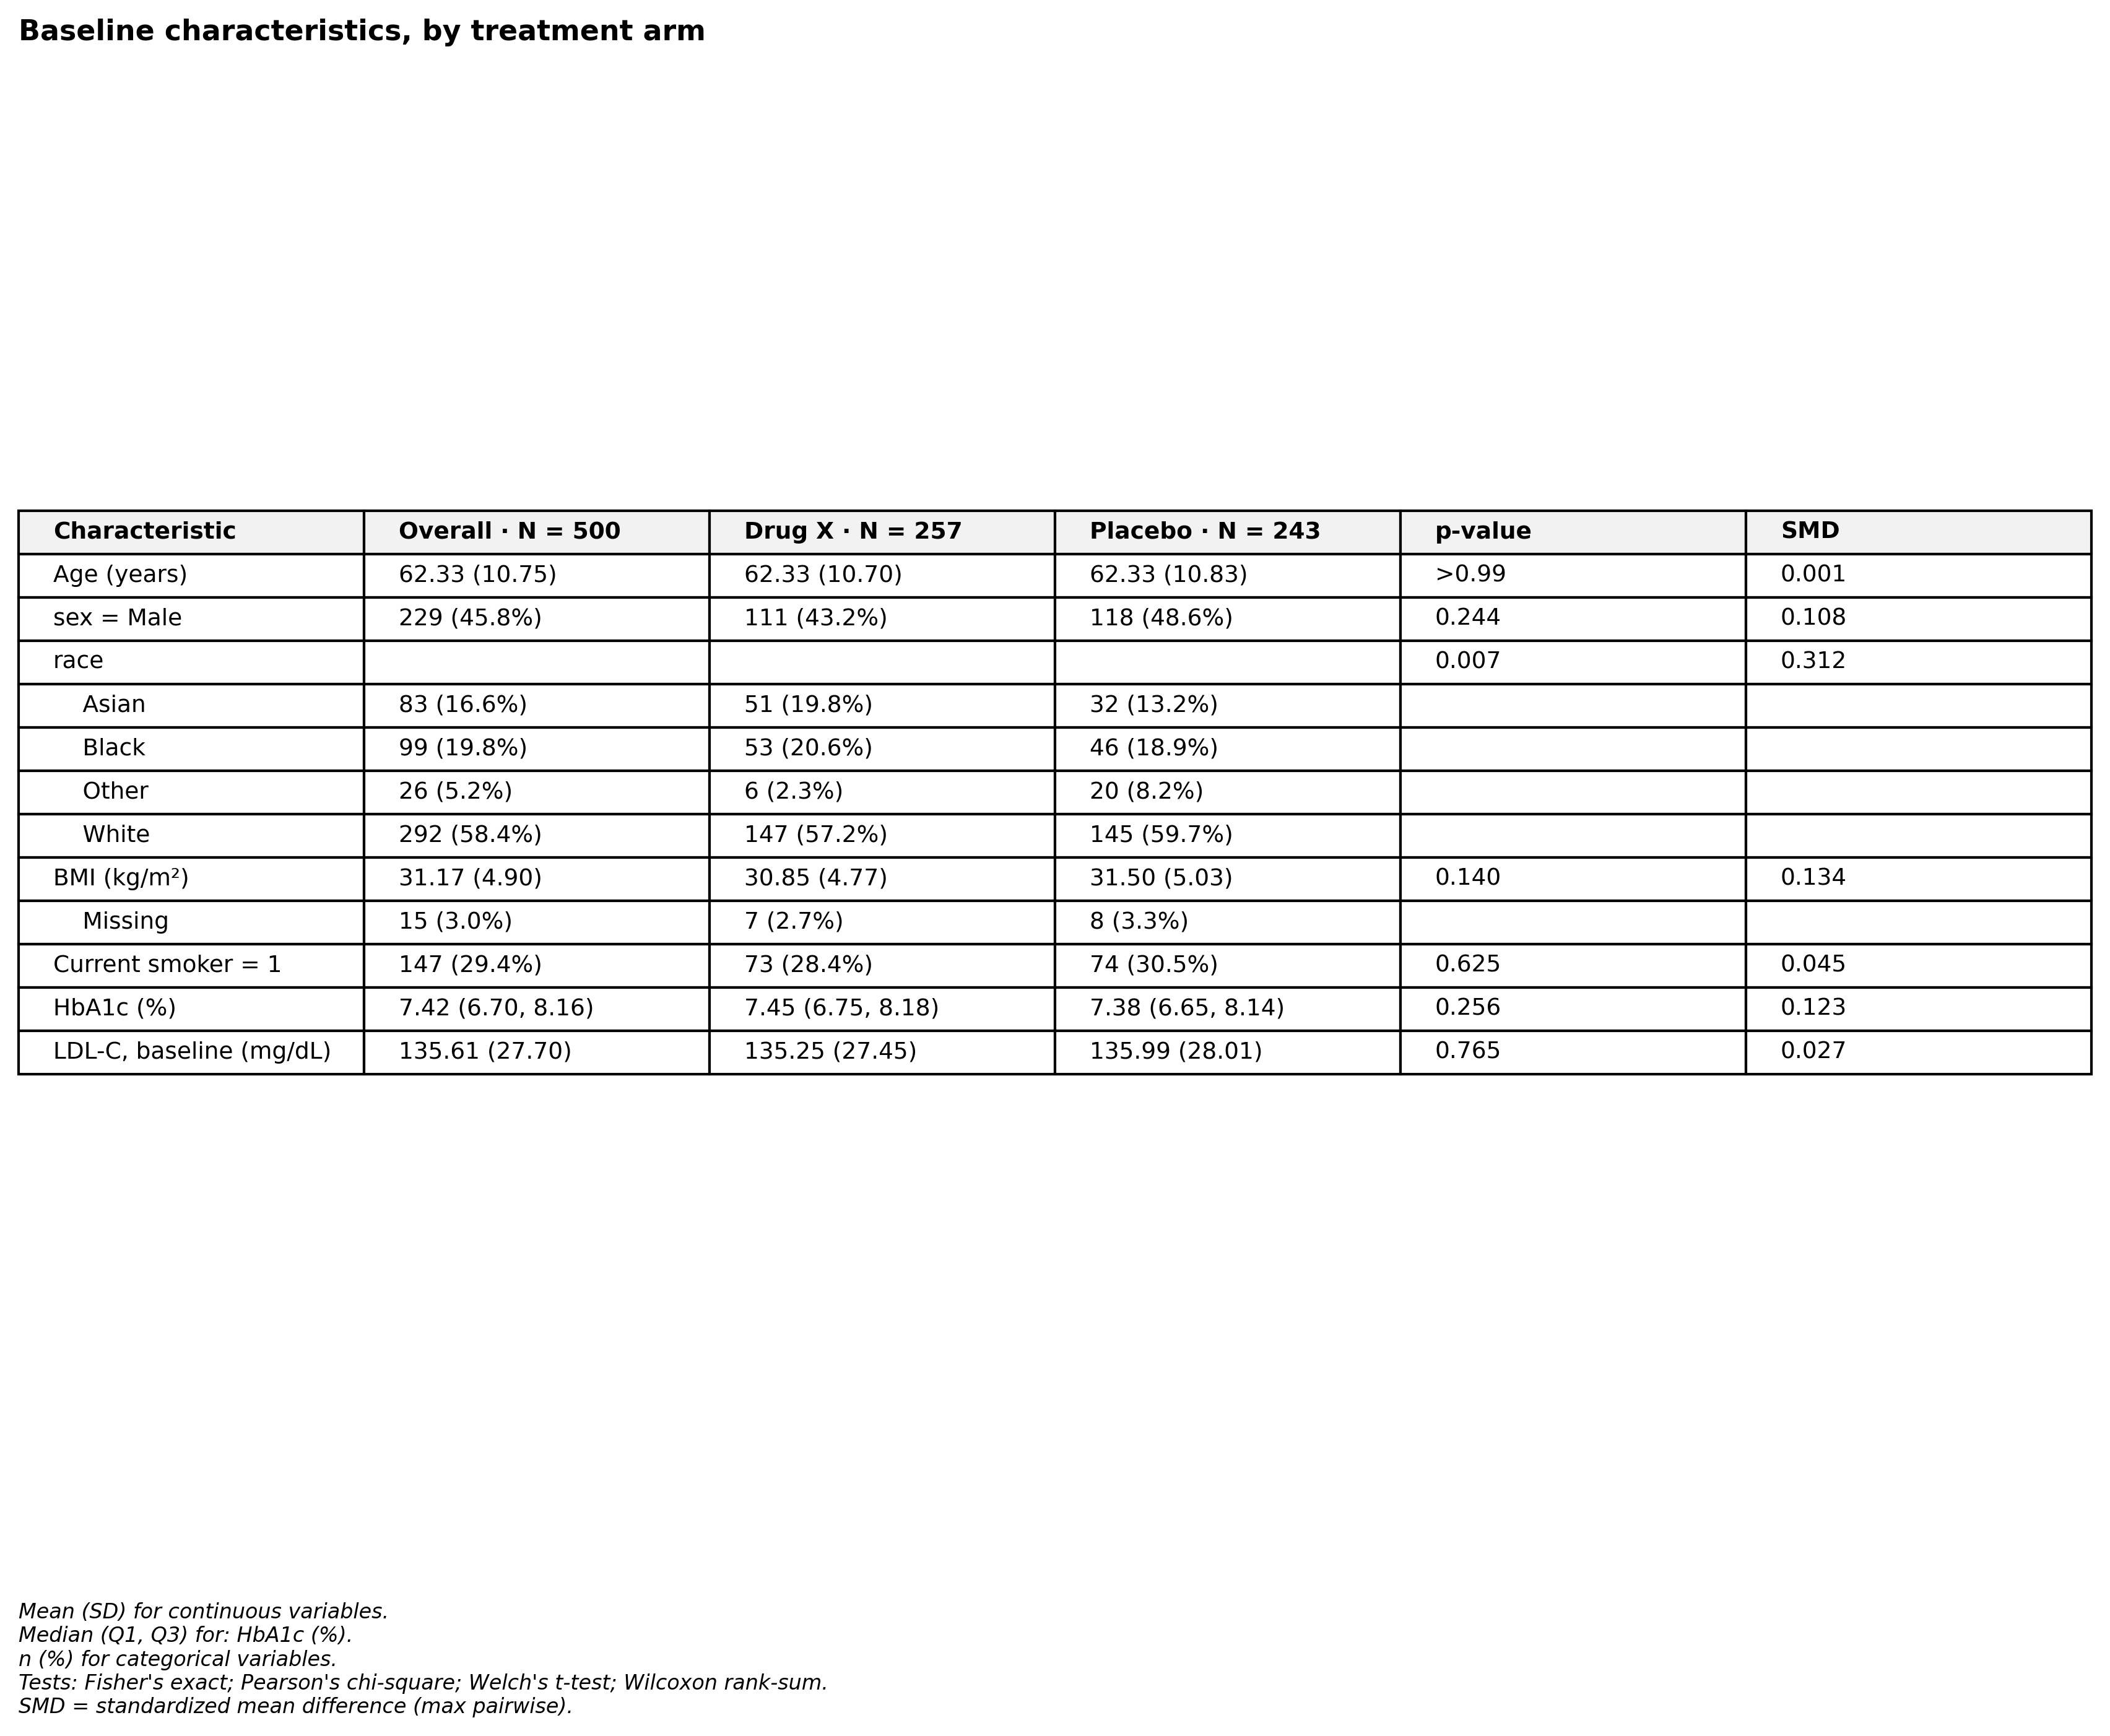

In [19]:
# Inline-embed the figure so the rendered HTML is self-contained.
from pathlib import Path
from IPython.display import Image

fig = Path("../assets/readme/table_one.png")
if fig.exists():
    display(Image(str(fig), width=900))
else:
    print(f"(figure not found at {fig})")


---

## Part XV — Where next

We've now driven every analytical surface in PySofra through one
coherent research question. To take this to your own data:

**Real CSVs.** The synthetic trial above is shape-compatible with
the kind of dataset you'd build for a real two-arm
trial. Any
`pd.read_csv(...)` / `pl.read_csv(...)` / `pd.read_parquet(...)` /
REDCap / SAS export works:

```python
df = pd.read_csv("trial.csv")
ps.tbl_one(df, by="arm").add_p().add_smd().add_overall().to_docx("table1.docx")
```

**polars natively.** PySofra accepts `polars.DataFrame` at every
builder. Useful for the lazy-frame / streaming workflows that
pandas can't quite reach.

```python
import polars as pl
df_pl = pl.read_csv("trial.csv")
ps.tbl_one(df_pl, by="arm").add_p()  # no .to_pandas() conversion needed
```

**Reproducibility.** Every renderer is byte-deterministic across
processes (Part XIII). Identical input always produces identical
HTML/Markdown/LaTeX, which is required for reproducible publication
artifacts.

**Cross-validation against R.** The test suite cross-checks the
core primitives (Welch t, Wilcoxon, Fisher, chi-square, GLM, KM,
log-rank) against direct calls to `scipy`, `statsmodels`, and
`lifelines` to machine precision
(`tests/test_statistical_correctness.py`).
**Where the docs live.** Long-form material is in `docs/`:

- `docs/guides/tbl_one.md` — variable-kind inference, test
  selection, override syntax
- `docs/guides/tbl_regression.md` — all supported model families,
  the `ModelSummary` extractor protocol
- `docs/guides/tbl_survival.md` — KM math, log-rank, Cox /
  Weibull AFT lifelines integration
- `docs/guides/weights.md` — `SurveyDesign(...)`, Rao–Scott,
  Taylor linearisation, design-adjusted *t*-test
- `docs/guides/themes.md` — the six builtins + `register_theme`

---

**Cheat sheet — every analytical surface in one block:**

```python
import pysofra as ps

# Describe — the descriptive trio
ps.tbl_one(df, by="arm").add_p().add_smd().add_overall()
ps.tbl_summary(df)                          # unstratified summary
ps.tbl_cross(df, row="sex", column="arm").add_p()

# Regress — one API, three model families
ps.tbl_regression(sm_fit, exponentiate=True).with_forest_plot()  # statsmodels
ps.tbl_regression(cph)                                            # lifelines CoxPH / AFT
ps.tbl_regression(sklearn_fit)                                    # binary or multi-class
ps.tbl_uvregression(df, outcome=, predictors=)                    # one row per predictor

# Survive — KM + Cox + log-rank
ps.tbl_survival(df, time=, event=, by=, times=[3, 6, 12]).with_km_plot()

# Pool — Rubin's rules over multiple imputations
pooled = ps.pool([fit_1, fit_2, fit_3])
ps.tbl_regression(pooled)

# Adjust — survey weights auto-dispatch
ps.tbl_one(df, by="arm", weights="w").add_p()        # auto-svyttest
ps.tbl_one(df, by="arm", design=ps.SurveyDesign(weights="w", strata="region", cluster="psu")).add_p()

# Compose — side-by-side or stacked
ps.tbl_merge([t1, t2], tab_spanners=["UV", "MV"])
ps.tbl_stack([t1, t2])

# Style — every modifier returns a new immutable table
.add_p() .add_q() .add_smd() .add_overall() .add_n() .add_stat_label()
.add_difference() .add_ci() .add_global_p(adjust_for=[...])
.add_significance_stars() .bold_p() .bold_if() .highlight_if()
.color_scale_if() .with_forest_plot() .with_km_plot()
.with_inline_svg() .with_pvalue_fmt() .with_estimate_fmt()
.with_footnotes() .theme("jama") .set_caption() .modify_spanning_header()

# Export — seven byte-deterministic backends from one SofraTable
.to_html() .to_markdown() .to_latex() .to_docx() .to_pptx() .to_xlsx() .to_image()
```

Read the [README](../README.md) for the design philosophy and the
[`pysofra_tutorial.ipynb`](pysofra_tutorial.ipynb) for the
end-to-end walkthrough that explains every modifier with comparison
notes against the R equivalents.

---

*PySofra — the missing statistical reporting layer for Python.*
